<a href="https://colab.research.google.com/github/werounikaa/AI_MED_Recruitment/blob/main/Recruitment_AI_MED_AGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#importing needed libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

## Problem Overview
The objective of this project is to build a machine learning model capable of automatically detecting hypertrophic cardiomyopathy (cardiomegaly). This is framed as a binary classification problem, where the goal is to correctly assign a patient to one of two classes:
- a healthy heart (0)
- a diseased heart (1)

To solve this problem, classical machine learning algorithms were utilized such as Logistic Regression and Random Forest.

## Dataset
The provided dataset is tabular and consists of selected geometric and imaging features extracted from patient examinations (e.g., heart and lung width, areas, structural ratios and inertia tensors).

## Data Loading and Scaling
In this section, the dataset is loaded into a Pandas DataFrame for initial inspection and preprocessing. After separating the features (X) from the target labels (y) and splitting the data into training (80%) and testing sets (20%) , feature scaling is applied.

Scaling is a crucial step, particularly for linear models like Logistic Regression, as it standardizes the range of independent variables. This ensures that features with naturally larger numeric values do not disproportionately influence the model's learning process.

In [16]:
# Importing the data from the CSV file, that contains the complete dataset that we’ll split
df = pd.read_csv('task_data.csv', decimal=',')

#separating features (X) from diagnosis (y)
y = df['Cardiomegaly']
X = df.drop(columns=['Cardiomegaly'])

#Splitting the dataset into training and testing parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Initialising scaller and scalling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)






## Model 1: Logistic Regression
In this section, a Logistic Regression model is trained to establish a performance baseline. Logistic Regression is a highly interpretable linear algorithm that estimates the probability of a binary outcome. It is particularly well-suited for medical datasets, where understanding the influence and weight of each individual feature is just as important as the final prediction itself.

In [17]:
#Initialising model
model_lr = LogisticRegression(random_state=42)

#Training
model_lr.fit(X_train, y_train)

#Diagnosing patients from the test set
y_pred_lr = model_lr.predict(X_test)

print("Predictions of diagnosis for the first 5 patients: ", y_pred_lr[:5])
print("Real diagnosis for the first 5 patients:   ", y_test[:5].values)

Predictions of diagnosis for the first 5 patients:  [0 0 1 1 1]
Real diagnosis for the first 5 patients:    [1 0 1 0 1]


###Model 1: Results and Metrics
In this section, the performance of the Logistic Regression model is evaluated using a classification report and a confusion matrix.

Accuracy of the model: 75.00%

Detailed classification report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.83      0.83      0.83         6

    accuracy                           0.75         8
   macro avg       0.67      0.67      0.67         8
weighted avg       0.75      0.75      0.75         8



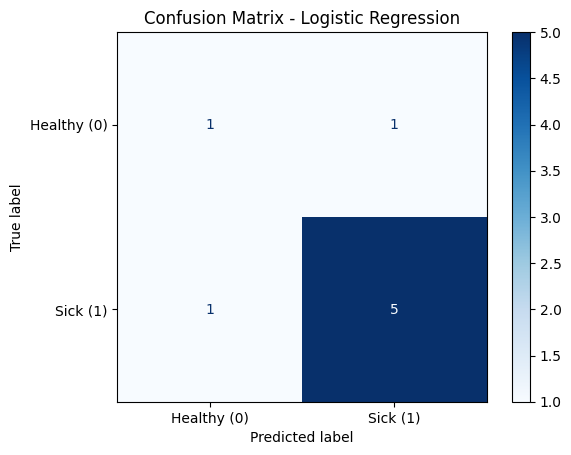

In [18]:

#Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the model: {accuracy * 100:.2f}%\n")

#Generating a detailed report
print("Detailed classification report:")
print(classification_report(y_test, y_pred_lr))

#Generating and drawing confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_test,
    y_test,
    display_labels=['Healthy (0)', 'Sick (1)'],
    cmap=plt.cm.Blues
)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
